In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import pyarrow.dataset as ds
import cv2
import gc

# ==========================================
# File paths
# ==========================================
base_path = '/root/autodl-tmp/st_data/LIHC'
cancer_type = 'LIHC'

transcripts_path = os.path.join(base_path, f"{cancer_type}_transcripts.parquet")
boundaries_path = os.path.join(base_path, f"{cancer_type}_cell_boundaries.csv")
nucleus_path = os.path.join(base_path, f"{cancer_type}_nucleus_boundaries.csv")
h5ad_path = os.path.join(base_path, f"st_{cancer_type}_test.h5ad")

# ==========================================
# Step 1 & 2: Load Imputed Reference & Map IDs
# ==========================================
adata_imputed = ad.read_h5ad(h5ad_path)
orig_ids = adata_imputed.obs_names.tolist()

orig_to_int = {orig: i + 1 for i, orig in enumerate(orig_ids)}
int_to_str = {i + 1: str(i + 1) for i in range(len(orig_ids))}
int_to_str[0] = "0"

adata_imputed.obs['cell_id'] = [int_to_str[orig_to_int[orig]] for orig in orig_ids]
imputed_genes = adata_imputed.var_names.tolist()
imputed_cells = set(adata_imputed.obs['cell_id'])

# ==========================================
# Step 3: Process Transcripts (Disk-level Filtering)
# ==========================================
dataset = ds.dataset(transcripts_path, format="parquet")
table = dataset.to_table(
    columns=['feature_name', 'x_location', 'y_location'],
    filter=(ds.field('is_gene') == True) & (ds.field('feature_name').isin(imputed_genes))
)
df_trans = table.to_pandas()
del table, dataset
gc.collect()

df_trans['bin_x'] = np.floor(df_trans['x_location'] / 2.0).astype(np.uint32)
df_trans['bin_y'] = np.floor(df_trans['y_location'] / 2.0).astype(np.uint32)
df_trans.drop(columns=['x_location', 'y_location'], inplace=True)

max_x_trans = df_trans['bin_x'].max() + 1
df_trans['bin_id_int'] = df_trans['bin_y'] * max_x_trans + df_trans['bin_x']

bin_ids, bin_uniques_int = pd.factorize(df_trans['bin_id_int'])
gene_ids, gene_uniques = pd.factorize(df_trans['feature_name'])

gene_map = {g: i for i, g in enumerate(imputed_genes)}
aligned_gene_ids = np.array([gene_map[gene_uniques[i]] for i in gene_ids], dtype=np.uint32)

X_raw = sp.coo_matrix((np.ones(len(df_trans), dtype=np.float32), (bin_ids, aligned_gene_ids)), 
                      shape=(len(bin_uniques_int), len(imputed_genes))).tocsr()

del df_trans, bin_ids, gene_ids, aligned_gene_ids
gc.collect()

bdata = ad.AnnData(X=X_raw)
bin_uniques_y, bin_uniques_x = np.divmod(bin_uniques_int, max_x_trans)
bdata.obs_names = [f"{x}_{y}" for x, y in zip(bin_uniques_x, bin_uniques_y)]
bdata.var_names = imputed_genes

bin_x_coords = bin_uniques_x.astype(np.uint32)
bin_y_coords = bin_uniques_y.astype(np.uint32)
bdata.obsm['spatial'] = np.column_stack((bin_x_coords, bin_y_coords)) * 2

# ==========================================
# Step 4: Local Bounding-Box Rasterization (Vectorized)
# ==========================================
bin_index_map = pd.Index(bin_uniques_int)

cell_id_array = np.zeros(len(bin_x_coords), dtype=np.int32)
nucleus_id_array = np.zeros(len(bin_x_coords), dtype=np.int32)

def rasterize_polygons_local(df_path, target_array, id_map):
    df = pd.read_csv(df_path, usecols=['cell_id', 'vertex_x', 'vertex_y'], 
                     dtype={'cell_id': str, 'vertex_x': np.float32, 'vertex_y': np.float32})
    
    df['cell_id_int'] = df['cell_id'].map(id_map).fillna(0).astype(np.int32)
    df = df[df['cell_id_int'] > 0]
    df.drop(columns=['cell_id'], inplace=True)
    
    df['grid_x'] = np.floor(df['vertex_x'] / 2.0).astype(np.int32)
    df['grid_y'] = np.floor(df['vertex_y'] / 2.0).astype(np.int32)
    
    for cid, group in df.groupby('cell_id_int'):
        pts = group[['grid_x', 'grid_y']].values
        min_x, min_y = pts.min(axis=0)
        max_x, max_y = pts.max(axis=0)
        
        w, h = max_x - min_x + 1, max_y - min_y + 1
        local_mask = np.zeros((h, w), dtype=np.uint8)
        
        local_pts = (pts - np.array([min_x, min_y])).astype(np.int32)
        cv2.fillPoly(local_mask, [local_pts.reshape((-1, 1, 2))], 1)
        
        local_y, local_x = np.where(local_mask == 1)
        global_x = local_x + min_x
        global_y = local_y + min_y
        
        global_int = global_y * max_x_trans + global_x
        idx = bin_index_map.get_indexer(global_int)
        
        valid_mask = idx != -1
        target_array[idx[valid_mask]] = cid
                
    del df
    gc.collect()

rasterize_polygons_local(boundaries_path, cell_id_array, orig_to_int)
rasterize_polygons_local(nucleus_path, nucleus_id_array, orig_to_int)

bdata.obs['cell_id_int'] = cell_id_array
bdata.obs['nucleus_id_int'] = nucleus_id_array

del bin_index_map, cell_id_array, nucleus_id_array
gc.collect()

# ==========================================
# Step 5: Format Final IDs
# ==========================================
bdata.obs['cell_id'] = bdata.obs['cell_id_int'].map(int_to_str).fillna("0").astype('category')
bdata.obs['nucleus_id'] = bdata.obs['nucleus_id_int'].map(int_to_str).fillna("0").astype('category')

# ==========================================
# Step 6: Vectorized Distribution (In-Place Optimized)
# ==========================================
if not sp.issparse(adata_imputed.X):
    adata_imputed.X = sp.csr_matrix(adata_imputed.X)

valid_mask = bdata.obs['cell_id'].isin(imputed_cells).values
valid_bin_indices = np.where(valid_mask)[0]
valid_cell_ids = bdata.obs['cell_id'].values[valid_mask]

imputed_id_to_idx = {cid: i for i, cid in enumerate(adata_imputed.obs['cell_id'])}
target_cell_indices = np.array([imputed_id_to_idx[cid] for cid in valid_cell_ids])

bin_raw_sums = np.asarray(bdata.X.sum(axis=1)).flatten()
valid_bin_weights = bin_raw_sums[valid_bin_indices]

sums_array = np.bincount(target_cell_indices, weights=valid_bin_weights)
cell_weight_sums = sums_array[target_cell_indices]

zero_mask = cell_weight_sums == 0
if zero_mask.any():
    counts_array = np.bincount(target_cell_indices)
    bin_counts = counts_array[target_cell_indices]
    valid_bin_weights[zero_mask] = 1.0
    cell_weight_sums[zero_mask] = bin_counts[zero_mask]

normalized_weights = valid_bin_weights / cell_weight_sums

M = sp.csr_matrix(
    (normalized_weights, (valid_bin_indices, target_cell_indices)), 
    shape=(bdata.n_obs, adata_imputed.n_obs),
    dtype=np.float32
)

X_imputed_distributed = M @ adata_imputed.X
del M, adata_imputed
gc.collect()

keep_mask = (~valid_mask).astype(np.float32)
Keep_Diag = sp.diags(keep_mask)
bdata.X = Keep_Diag @ bdata.X
del Keep_Diag
gc.collect()

bdata.X = bdata.X + X_imputed_distributed
del X_imputed_distributed
gc.collect()

bdata.obs.drop(columns=['cell_id_int', 'nucleus_id_int'], inplace=True, errors='ignore')

In [2]:
bdata

AnnData object with n_obs × n_vars = 13427299 × 10000
    obs: 'cell_id', 'nucleus_id'
    obsm: 'spatial'

In [3]:
import scanpy as sc

bdata.var_names_make_unique()
sc.pp.filter_genes(bdata, min_cells=3)
sc.pp.filter_cells(bdata, min_counts=1.5)

bdata

AnnData object with n_obs × n_vars = 12715913 × 3053
    obs: 'cell_id', 'nucleus_id', 'n_counts'
    var: 'n_cells'
    obsm: 'spatial'

In [4]:
bdata.write_h5ad('/root/autodl-tmp/st_data/LIHC/st_LIHC_test_preprocessed.h5ad')

In [5]:
# 1. 定义需要计算的分位数列表
quantiles = [0.01, 0.03, 0.05, 0.10, 0.30, 0.50, 0.70, 0.95, 0.99]

# 2. 计算分位数
counts_quantiles = bdata.obs['n_counts'].quantile(quantiles)

# 3. 打印结果
print("--- n_counts Quantiles ---")
for q, val in counts_quantiles.items():
    print(f"{int(q * 100):2d}% : {val:.2f}")

--- n_counts Quantiles ---
 1% : 2.00
 3% : 2.00
 5% : 2.71
10% : 4.00
30% : 8.99
50% : 13.75
70% : 18.98
95% : 30.80
99% : 38.95


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. 提取全局坐标与表达量
x = bdata.obsm['spatial'][:, 0]
y = bdata.obsm['spatial'][:, 1]
counts = bdata.obs['n_counts'].values

# 统计并打印全局坐标边界
print(f"X range: {x.min()} to {x.max()}")
print(f"Y range: {y.min()} to {y.max()}")

X range: 26 to 8448
Y range: 12 to 10838


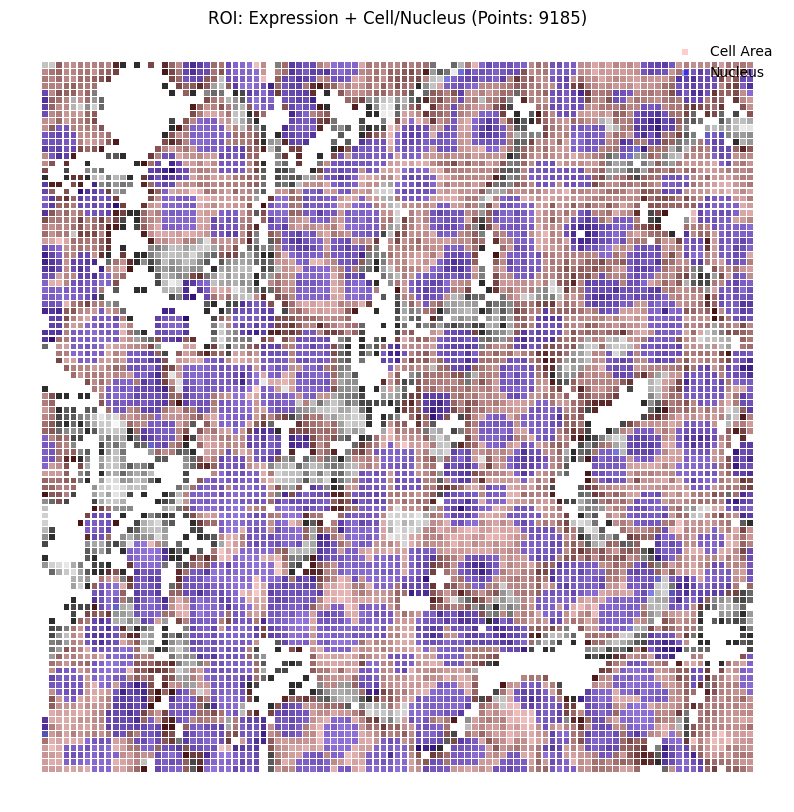

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. 设定 ROI 边界及掩码
roi_x_min, roi_x_max = 2000, 2200
roi_y_min, roi_y_max = 5000, 5200

x = bdata.obsm['spatial'][:, 0]
y = bdata.obsm['spatial'][:, 1]
counts = bdata.obs['n_counts'].values

mask = (x >= roi_x_min) & (x <= roi_x_max) & (y >= roi_y_min) & (y <= roi_y_max)
x_roi = x[mask]
y_roi = y[mask]
counts_roi = counts[mask]

# 2. 提取标签并转换为字符串
cell_ids_roi = bdata.obs['cell_id'].astype(str).values[mask]
nuc_ids_roi = bdata.obs['nucleus_id'].astype(str).values[mask]

# 3. 过滤背景标签 (排除 '0', '-1', 'nan' 等常见背景值)
bg_labels = ['0', '-1', 'nan', 'None', '']
is_cell = ~np.isin(cell_ids_roi, bg_labels)
is_nuc = ~np.isin(nuc_ids_roi, bg_labels)

# 4. 绘制多图层叠加的可视化
plt.figure(figsize=(10, 10))

# 图层 1: 全局表达谱 (灰度底图)
m = 17
plt.scatter(
    x_roi, y_roi, 
    c=counts_roi, cmap='gray', norm=LogNorm(vmin=1), 
    s=m, marker='s', edgecolors='none'
)

# 图层 2: 细胞区域 (红色，低透明度)
plt.scatter(
    x_roi[is_cell], y_roi[is_cell], 
    c='red', alpha=0.2, 
    s=m, marker='s', edgecolors='none', label='Cell Area'
)

# 图层 3: 细胞核区域 (蓝色，中透明度)
plt.scatter(
    x_roi[is_nuc], y_roi[is_nuc], 
    c='blue', alpha=0.4, 
    s=m, marker='s', edgecolors='none', label='Nucleus'
)

plt.axis('equal')
plt.axis('off')
plt.legend(loc='upper right', frameon=False)
plt.title(f"ROI: Expression + Cell/Nucleus (Points: {len(x_roi)})")
plt.show()

In [ ]:
# 1. 检查当前矩阵的真实稀疏度
total_elements = bdata.X.shape[0] * bdata.X.shape[1]
non_zeros = bdata.X.nnz
sparsity = 1.0 - (non_zeros / total_elements)
print(f"Non-zero elements: {non_zeros}")
print(f"Sparsity (Zero percentage): {sparsity:.2%}")

# 2. 强制恢复稀疏性（截断极小值）并释放内存
# 假设小于 0.01 的表达量为插补噪音
bdata.X.data[bdata.X.data < 0.01] = 0
bdata.X.eliminate_zeros()

# 3. 再次检查清理后的内存大小
from scipy import sparse
new_size_gb = (bdata.X.data.nbytes + bdata.X.indices.nbytes + bdata.X.indptr.nbytes) / (1024**3)
print(f"New X size: {new_size_gb:.4f} GB")

Non-zero elements: 4094587100
Sparsity (Zero percentage): 89.37%
New X size: 43.6257 GB
